In [9]:
%pip install -q tqdm gdown datasets

In [10]:
from google.colab import drive
from pathlib import Path
import json, io, pickle, math
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from tqdm.auto import tqdm
from PIL import Image

drive.mount('/content/drive')

# ─── Paths ───────────────────────────────────────────────────────────────────
RAR_PATH       = Path('/content/drive/MyDrive/Dataset/CASIA-Webface/casia-webface.rar')
EXTRACT_DIR    = Path('/tmp/casia-webface')
CHECKPOINT_DIR = Path('/content/drive/MyDrive/arcface_casia4/checkpoints')
LOG_DIR        = Path('/content/drive/MyDrive/arcface_casia4/logs')
LFW_BIN_PATH   = Path('/content/drive/MyDrive/Dataset/lfw/lfw.bin')

for p in [EXTRACT_DIR, CHECKPOINT_DIR, LOG_DIR, LFW_BIN_PATH.parent]:
    p.mkdir(parents=True, exist_ok=True)

# ─── Hyperparameters (theo repo Xiaoccer/MobileFaceNet_Pytorch) ───────────────
NUM_CLASSES    = 10_575       # ghi đè sau khi load data
EMBEDDING_SIZE = 128          # ← 128-dim (đúng theo paper & repo gốc, KHÔNG phải 512)

ARC_S          = 32.0         # scale
ARC_M          = 0.5          # angular margin

BATCH_SIZE     = 256          # repo gốc dùng 2 GPU × 256; Colab T4 dùng 512 với AMP
TOTAL_EPOCH    = 50           # repo gốc: 70 epochs
LR             = 0.05          # repo gốc: lr=0.1
MOMENTUM       = 0.9
LR_MILESTONES  = [30, 40, 46] # repo gốc: milestones=[36, 52, 58]
LR_GAMMA       = 0.1
MAX_GRAD_NORM  = 5.0
NUM_WORKERS    = 2

# weight_decay riêng cho từng nhóm (theo train.py gốc)
WD_BASE        = 4e-5         # conv/bn layers
WD_CLASSIFIER  = 4e-4         # linear1 + ArcMargin.weight
WD_PRELU       = 0.0          # PReLU params không regularize

SAVE_FREQ      = 5            # lưu checkpoint mỗi N epoch
TEST_FREQ      = 1            # eval LFW mỗi N epoch

BEST_PATH = CHECKPOINT_DIR / 'best_model.ckpt'
LAST_PATH = CHECKPOINT_DIR / 'last_model.ckpt'
LOG_PATH  = LOG_DIR / 'history.json'

print('Config OK.')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}  VRAM: {props.total_memory/1e9:.1f}GB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config OK.
CUDA available: True
GPU: Tesla T4  VRAM: 15.6GB


In [11]:
import subprocess, shutil

LOCAL_RAR  = Path('/tmp/casia-webface.rar')
LOCAL_DIR  = Path('/tmp/casia-webface')

# Bước 1: Copy .rar từ Drive vào /tmp
if not LOCAL_RAR.exists():
    print('Đang copy .rar từ Drive vào /tmp ...')
    shutil.copy2(str(RAR_PATH), str(LOCAL_RAR))
    print('Xong.')
else:
    print('File .rar đã có trong /tmp — bỏ qua copy.')

# Bước 2: Giải nén tại /tmp
if LOCAL_DIR.exists() and any(LOCAL_DIR.iterdir()):
    print('Dataset đã giải nén — bỏ qua.')
else:
    print('Đang giải nén ...')
    subprocess.run(['apt-get', 'install', '-y', '-q', 'unrar'], check=True)
    r = subprocess.run(['unrar', 'x', '-y', str(LOCAL_RAR), str(LOCAL_DIR) + '/'],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'Giải nén thất bại!\n{r.stderr}')
    print('Giải nén xong.')

DATA_ROOT = LOCAL_DIR
subdirs = [d for d in LOCAL_DIR.iterdir() if d.is_dir()]
if len(subdirs) == 1:
    DATA_ROOT = subdirs[0]

n_ids = len([d for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f'DATA_ROOT : {DATA_ROOT}  |  {n_ids} identities')

File .rar đã có trong /tmp — bỏ qua copy.
Dataset đã giải nén — bỏ qua.
DATA_ROOT : /tmp/casia-webface/casia-webface  |  10572 identities


## Model — MobileFacenet + ArcMarginProduct (theo repo Xiaoccer)

### Kiến trúc MobileFacenet (đúng theo paper & model.py gốc)

```
Input (3×112×96)
  → Conv2d(3→64, 3×3, s=2) + BN + PReLU          # stem
  → DWConv(64→64, 3×3, s=1) + BN + PReLU          # depthwise
  → Bottleneck blocks (MobileNetV2-style):
       t=2, c=64,  n=5, s=2
       t=4, c=128, n=1, s=2
       t=2, c=128, n=6, s=1
       t=4, c=128, n=1, s=2
       t=2, c=128, n=2, s=1
  → Conv2d(128→512, 1×1) + BN + PReLU             # pointwise expansion
  → GDC: Conv2d(512→512, 7×7, dw) + BN           # Global Depthwise Conv
  → Flatten → Linear(512→128) → BN1d             # linear1: embedding
Output: 128-dim embedding (KHÔNG normalize ở đây)
```

**Điểm khác biệt so với v3:**
- Output **128-dim** (v3 dùng 512)
- `linear1` được tách riêng trong optimizer với `weight_decay=4e-4`
- `ArcMarginProduct` nhận input 128-dim
- Input size 112×96 (rectangular, theo SphereFace preprocessing)

In [12]:
class ConvBN(nn.Module):
    """Conv2d + BN + PReLU"""
    def __init__(self, inp, oup, k=3, s=1, p=1, groups=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(inp, oup, k, s, p, groups=groups, bias=False),
            nn.BatchNorm2d(oup),
            nn.PReLU(oup),
        )
    def forward(self, x): return self.block(x)


class Bottleneck(nn.Module):
    """
    MobileNetV2-style inverted residual block.
    Dùng PReLU thay ReLU6 (theo MobileFaceNet paper).
    """
    def __init__(self, inp, oup, stride, expand_ratio):
        super().__init__()
        hidden = inp * expand_ratio
        self.use_res = (stride == 1 and inp == oup)
        self.conv = nn.Sequential(
            # pw: pointwise expansion
            nn.Conv2d(inp, hidden, 1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.PReLU(hidden),
            # dw: depthwise conv
            nn.Conv2d(hidden, hidden, 3, stride, 1, groups=hidden, bias=False),
            nn.BatchNorm2d(hidden),
            nn.PReLU(hidden),
            # pw-linear: pointwise projection (NO activation — linear bottleneck)
            nn.Conv2d(hidden, oup, 1, bias=False),
            nn.BatchNorm2d(oup),
        )

    def forward(self, x):
        return x + self.conv(x) if self.use_res else self.conv(x)


class MobileFacenet(nn.Module):
    """
    MobileFaceNet theo paper & repo Xiaoccer/MobileFaceNet_Pytorch.

    Block config: (expand_ratio t, channels c, num_blocks n, stride s)
    Theo Table 2 trong paper MobileFaceNets (Chen et al., 2018).

    Input : (B, 3, 112, 96)  — SphereFace-aligned
    Output: (B, 128)          — unnormalized embedding
    """
    # (t, c, n, s)
    CFG = [
        (2,  64,  5, 2),
        (4, 128,  1, 2),
        (2, 128,  6, 1),
        (4, 128,  1, 2),
        (2, 128,  2, 1),
    ]

    def __init__(self, emb=128):
        super().__init__()
        # Stem: Conv + DW
        self.conv1   = ConvBN(3, 64, k=3, s=2, p=1)           # 112×96 → 56×48
        self.dw_conv = ConvBN(64, 64, k=3, s=1, p=1, groups=64)  # depthwise

        # Bottleneck blocks
        layers, inp = [], 64
        for t, c, n, s in self.CFG:
            for i in range(n):
                layers.append(Bottleneck(inp, c, stride=s if i == 0 else 1,
                                         expand_ratio=t))
                inp = c
        self.blocks = nn.Sequential(*layers)

        # Pointwise expansion: 128 → 512
        self.conv2   = ConvBN(128, 512, k=1, s=1, p=0)          # 7×6 → 7×6

        # GDC — Global Depthwise Convolution (7×6 → 1×1)
        # Input là 112×96 → sau 4 stride-2: 7×6
        self.gdc     = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=(7, 6), groups=512, bias=False),
            nn.BatchNorm2d(512),
        )

        # linear1: embedding layer — tách ra cho optimizer weight_decay riêng
        self.linear1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, emb, bias=False),
            nn.BatchNorm1d(emb),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
            elif isinstance(m, nn.PReLU):
                nn.init.constant_(m.weight, 0.25)

    def forward(self, x):
        x = self.conv1(x)
        x = self.dw_conv(x)
        x = self.blocks(x)
        x = self.conv2(x)
        x = self.gdc(x)
        x = self.linear1(x)
        return x   # (B, 128) — unnormalized


class ArcMarginProduct(nn.Module):
    """
    ArcFace (ArcMarginProduct) theo model.py gốc của Xiaoccer.
    Input embedding KHÔNG cần normalize trước — module tự normalize.
    Weight có shape (num_classes, emb_size) — tách ra trong optimizer.
    """
    def __init__(self, emb_size: int, num_classes: int,
                 s: float = 32.0, m: float = 0.5):
        super().__init__()
        self.weight  = nn.Parameter(torch.empty(num_classes, emb_size))
        nn.init.xavier_uniform_(self.weight)
        self.s      = s
        self.m      = m
        self.cos_m  = math.cos(m)
        self.sin_m  = math.sin(m)
        self.th     = math.cos(math.pi - m)      # boundary
        self.mm     = math.sin(math.pi - m) * m  # mm = sin(pi-m)*m

    def forward(self, x: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        # Normalize
        x_norm = F.normalize(x.float(), dim=1)
        W_norm = F.normalize(self.weight.float(), dim=1)

        cos_theta   = F.linear(x_norm, W_norm).clamp(-1 + 1e-7, 1 - 1e-7)
        sin_theta   = torch.sqrt(1.0 - cos_theta ** 2)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m  # cos(θ+m)

        # Hard margin boundary (tránh gradient âm)
        cos_theta_m = torch.where(
            cos_theta > self.th,
            cos_theta_m,
            cos_theta - self.mm,
        )

        one_hot = torch.zeros_like(cos_theta).scatter_(1, labels.view(-1, 1), 1.0)
        logits  = one_hot * cos_theta_m + (1.0 - one_hot) * cos_theta
        return logits * self.s


# ── Sanity check kích thước ─────────────────────────────────────────────────
def _sanity_check():
    net = MobileFacenet(128)
    x   = torch.randn(2, 3, 112, 96)   # SphereFace-aligned input
    out = net(x)
    assert out.shape == (2, 128), f'Expected (2,128), got {out.shape}'
    arc = ArcMarginProduct(128, 10575)
    lbl = torch.tensor([0, 1])
    logits = arc(out, lbl)
    assert logits.shape == (2, 10575), f'Expected (2,10575), got {logits.shape}'
    n_params = sum(p.numel() for p in net.parameters())
    print(f'MobileFacenet params: {n_params:,}  (~{n_params/1e6:.2f}M)')
    print('Sanity check PASSED — output shape:', out.shape)

_sanity_check()
print('Models defined.')

MobileFacenet params: 999,552  (~1.00M)
Sanity check PASSED — output shape: torch.Size([2, 128])
Models defined.


## DataLoader

**Input size 112×96** theo SphereFace preprocessing (repo gốc dùng `lfw-112X96`).
Nếu dataset của bạn đã crop 112×112, đổi `Resize` thành `(112, 112)`.

In [13]:
# ─── Transforms ─────────────────────────────────────────────────────────────
# Input 112×96 (SphereFace-aligned) — theo repo gốc
# Nếu dataset crop 112×112, đổi thành transforms.Resize((112, 112))
T_train = transforms.Compose([
    transforms.Resize((112, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

T_eval = transforms.Compose([
    transforms.Resize((112, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

T_eval_flip = transforms.Compose([
    transforms.Resize((112, 96)),
    transforms.functional.hflip if False else transforms.Lambda(lambda x: x),  # placeholder
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

full_dataset = datasets.ImageFolder(str(DATA_ROOT), transform=T_train)
NUM_CLASSES  = len(full_dataset.classes)

train_loader = DataLoader(
    full_dataset,
    batch_size        = BATCH_SIZE,
    shuffle           = True,
    num_workers       = NUM_WORKERS,
    pin_memory        = True,
    persistent_workers= True,
    prefetch_factor   = 2,
    drop_last         = False,  # repo gốc: drop_last=False
)

TRAIN_STEPS = len(train_loader)
print(f'NUM_CLASSES : {NUM_CLASSES}')
print(f'Train images: {len(full_dataset):,}')
print(f'Steps/epoch : {TRAIN_STEPS}  (batch={BATCH_SIZE})')
print(f'Input size  : 112×96 (SphereFace-aligned)')

NUM_CLASSES : 10572
Train images: 490,623
Steps/epoch : 1917  (batch=256)
Input size  : 112×96 (SphereFace-aligned)


## LFW Evaluation — flip-concat (theo lfw_eval.py gốc)

Repo gốc trích xuất feature theo cách:
```python
res = [net(d) for d in data]  # data = [img_orig, img_flip, img_orig_R, img_flip_R]
featureL = concat(res[0], res[1])  # 128 + 128 = 256-dim
featureR = concat(res[2], res[3])  # 128 + 128 = 256-dim
```
Sau đó normalize bằng mean-subtraction + L2 (trong `evaluation_10_fold`).

In [14]:
def load_lfw_bin(bin_path: Path):
    """Load lfw.bin (insightface format: bins=list of jpg bytes, labels=array)."""
    with open(bin_path, 'rb') as f:
        bins, labels = pickle.load(f, encoding='bytes')
    return bins, np.array(labels, dtype=np.int32)


def _img_from_bin(b):
    """bytes → PIL.Image RGB"""
    return Image.open(io.BytesIO(b)).convert('RGB')


@torch.no_grad()
def extract_lfw_embeddings_flipconcat(model, bins, device, batch_size=256):
    """
    Trích xuất embedding theo cách của repo gốc:
    - Mỗi ảnh được forward 2 lần: gốc + flip ngang
    - Kết quả concat: (B, 256) — giống `np.concatenate((res[0], res[1]), 1)`
    """
    model.eval()
    all_embs = []
    buf_orig, buf_flip = [], []

    def _flush():
        if not buf_orig:
            return
        t_orig = torch.stack(buf_orig).to(device)
        t_flip = torch.stack(buf_flip).to(device)
        e_orig = model(t_orig).float().cpu()  # (B, 128)
        e_flip = model(t_flip).float().cpu()  # (B, 128)
        all_embs.append(torch.cat([e_orig, e_flip], dim=1))  # (B, 256)
        buf_orig.clear(); buf_flip.clear()

    for i, b in enumerate(bins):
        img = _img_from_bin(b)
        buf_orig.append(T_eval(img))
        buf_flip.append(T_eval(img.transpose(Image.FLIP_LEFT_RIGHT)))
        if len(buf_orig) == batch_size or i == len(bins) - 1:
            _flush()

    return torch.cat(all_embs, dim=0)   # (12000, 256)


def lfw_10fold_flipconcat(embs: torch.Tensor, labels: np.ndarray):
    """
    10-fold evaluation theo `evaluation_10_fold` trong lfw_eval.py gốc.
    Dùng mean-subtraction + L2 normalization trên từng fold.
    """
    embs_np = embs.numpy()       # (12000, 256)
    embs_l  = embs_np[0::2]     # (6000, 256)
    embs_r  = embs_np[1::2]     # (6000, 256)
    n       = len(labels)        # 6000
    fold_size = n // 10          # 600

    accs = np.zeros(10)
    thresholds = []

    for fold in range(10):
        # val/test split
        fold_arr  = np.arange(n) // fold_size  # fold index per sample
        val_mask  = (fold_arr != fold)
        test_mask = (fold_arr == fold)

        # Mean-subtraction (theo evaluation_10_fold gốc)
        mu = np.mean(
            np.concatenate((embs_l[val_mask], embs_r[val_mask]), axis=0),
            axis=0, keepdims=True
        )
        fl = embs_l - mu
        fr = embs_r - mu

        # L2 normalize
        fl = fl / (np.linalg.norm(fl, axis=1, keepdims=True) + 1e-12)
        fr = fr / (np.linalg.norm(fr, axis=1, keepdims=True) + 1e-12)

        scores = np.sum(fl * fr, axis=1)  # cosine similarity, (6000,)
        flags  = labels.astype(int) * 2 - 1  # 1 → +1 (same), 0 → -1 (diff)

        # Tìm ngưỡng tốt nhất trên val fold (thrNum=10000 theo gốc)
        thr_range = np.arange(-10000, 10001) * 1.0 / 10000
        val_scores = scores[val_mask]
        val_flags  = flags[val_mask]
        accs_thr = np.array([
            ((val_scores[val_flags == 1] >= t).sum() +
             (val_scores[val_flags == -1] < t).sum()) / len(val_scores)
            for t in thr_range
        ])
        best_t = float(np.mean(thr_range[accs_thr == accs_thr.max()]))
        thresholds.append(best_t)

        # Đánh giá trên test fold
        test_scores = scores[test_mask]
        test_flags  = flags[test_mask]
        accs[fold]  = (
            (test_scores[test_flags == 1] >= best_t).sum() +
            (test_scores[test_flags == -1] < best_t).sum()
        ) / len(test_scores)

    return accs.mean(), accs.std(), float(np.mean(thresholds))


@torch.no_grad()
def evaluate_lfw(model, lfw_bin_path: Path, device, verbose=True):
    bins, labels         = load_lfw_bin(lfw_bin_path)
    embs                 = extract_lfw_embeddings_flipconcat(model, bins, device)
    mean_acc, std, thresh = lfw_10fold_flipconcat(embs, labels)
    if verbose:
        print(f'LFW: {mean_acc*100:.3f}% ± {std*100:.3f}%  |  threshold={thresh:.4f}')
    return mean_acc, std, thresh


print('LFW eval functions ready (flip-concat mode, 256-dim).')

LFW eval functions ready (flip-concat mode, 256-dim).


## Khởi tạo Model, Optimizer (theo train.py gốc)

Optimizer tách **4 nhóm param** với weight_decay khác nhau:
```
base_params     → weight_decay = 4e-5   (conv, bn)
linear1 params  → weight_decay = 4e-4   (embedding layer)
ArcMargin.weight→ weight_decay = 4e-4   (classifier weight)
PReLU params    → weight_decay = 0.0    (không regularize activation)
```

In [15]:
import gc
torch.cuda.empty_cache()
gc.collect()

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = torch.cuda.is_available()

net       = MobileFacenet(EMBEDDING_SIZE).to(device)
ArcMargin = ArcMarginProduct(EMBEDDING_SIZE, NUM_CLASSES, ARC_S, ARC_M).to(device)
criterion = nn.CrossEntropyLoss().to(device)

# ─── Optimizer: tách 4 nhóm param (theo train.py gốc) ─────────────────────
ignored_params  = list(map(id, net.linear1.parameters()))
ignored_params += list(map(id, ArcMargin.weight))

prelu_params = []
for m in net.modules():
    if isinstance(m, nn.PReLU):
        ignored_params += list(map(id, m.parameters()))
        prelu_params   += list(m.parameters())

base_params = [p for p in net.parameters() if id(p) not in ignored_params]

optimizer = torch.optim.SGD(
    [
        {'params': base_params,              'weight_decay': WD_BASE},
        {'params': net.linear1.parameters(), 'weight_decay': WD_CLASSIFIER},
        {'params': [ArcMargin.weight],       'weight_decay': WD_CLASSIFIER},
        {'params': prelu_params,             'weight_decay': WD_PRELU},
    ],
    lr=LR, momentum=MOMENTUM, nesterov=True,
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=LR_MILESTONES, gamma=LR_GAMMA
)

scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
history, best_lfw_acc, start_epoch, global_step = [], 0.0, 1, 0

# ─── Resume từ checkpoint ──────────────────────────────────────────────────
if LAST_PATH.exists():
    ckpt = torch.load(str(LAST_PATH), map_location=device, weights_only=False)
    ok   = all(
        torch.isfinite(v).all()
        for v in ckpt.get('net_state_dict', {}).values()
        if isinstance(v, torch.Tensor)
    )
    if ok:
        net.load_state_dict(ckpt['net_state_dict'])
        ArcMargin.load_state_dict(ckpt['arcmargin_state_dict'])
        optimizer.load_state_dict(ckpt.get('optimizer_state_dict', {}))
        scheduler.load_state_dict(ckpt.get('scheduler_state_dict', {}))
        best_lfw_acc = float(ckpt.get('best_lfw_acc', 0.0))
        start_epoch  = int(ckpt.get('epoch', 0)) + 1
        global_step  = int(ckpt.get('global_step', 0))
        if LOG_PATH.exists():
            history = json.loads(LOG_PATH.read_text())

        # Phục hồi LR đúng sau khi load
        if hasattr(scheduler, '_last_lr') and scheduler._last_lr:
            for pg, lr_val in zip(optimizer.param_groups, scheduler._last_lr):
                pg['lr'] = lr_val
            print(f'Resumed epoch {start_epoch} | best LFW={best_lfw_acc*100:.3f}% | LR={scheduler._last_lr[0]:.2e}')
        else:
            lr_resumed = LR * (LR_GAMMA ** sum(1 for m in LR_MILESTONES if m < start_epoch - 1))
            for pg in optimizer.param_groups:
                pg['lr'] = lr_resumed
            print(f'Resumed epoch {start_epoch} | best LFW={best_lfw_acc*100:.3f}% | LR={lr_resumed:.2e} (fallback)')
    else:
        print('Checkpoint có NaN — bắt đầu từ đầu.')
else:
    print('Không có checkpoint, train từ đầu.')

print()
print(f'Device   : {device}  |  AMP={use_amp}')
print(f'Model    : MobileFacenet  emb={EMBEDDING_SIZE}-dim')
print(f'ArcFace  : s={ARC_S}, m={ARC_M}')
print(f'Optim    : SGD lr={LR}, momentum={MOMENTUM}, nesterov=True')
print(f'Schedule : MultiStepLR milestones={LR_MILESTONES}, gamma={LR_GAMMA}')
print(f'WD groups: base={WD_BASE}, classifier={WD_CLASSIFIER}, prelu={WD_PRELU}')
print(f'Epochs   : {TOTAL_EPOCH}  (resume from {start_epoch})')
if torch.cuda.is_available():
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB')

Resumed epoch 20 | best LFW=98.917% | LR=5.00e-02

Device   : cuda  |  AMP=True
Model    : MobileFacenet  emb=128-dim
ArcFace  : s=32.0, m=0.5
Optim    : SGD lr=0.05, momentum=0.9, nesterov=True
Schedule : MultiStepLR milestones=[30, 40, 46], gamma=0.1
WD groups: base=4e-05, classifier=0.0004, prelu=0.0
Epochs   : 50  (resume from 20)
VRAM     : 15.6GB


## Training Loop

**Ước tính thời gian trên T4 (BATCH=512, AMP fp16):**

| Epoch | LR | Tích lũy |
|---|---|---|
| 1–36 | 0.1 | ~4.2 giờ |
| 37–52 | 0.01 | +1.9 giờ |
| 53–58 | 0.001 | +0.7 giờ |
| 59–70 | 0.0001 | +1.4 giờ |
| **Tổng** | | **~8.2 giờ** |

→ Nên dùng **Colab Pro** hoặc chia nhỏ session (checkpoint mỗi `SAVE_FREQ` epoch).

In [16]:
import time

print(f'Training {TOTAL_EPOCH} epochs | {NUM_CLASSES} classes | {device}')
print('=' * 70)

for epoch in range(start_epoch, TOTAL_EPOCH + 1):
    t_epoch_start = time.time()
    net.train(); ArcMargin.train()
    loss_sum = correct_sum = total_sum = gn_sum = steps = 0

    pbar = tqdm(train_loader, desc=f'Ep {epoch:3d}/{TOTAL_EPOCH}', leave=False)
    for step, (imgs, lbls) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            raw_logits  = net(imgs)                   # (B, 128)
            output      = ArcMargin(raw_logits, lbls) # (B, num_classes)
            total_loss  = criterion(output, lbls)

        if not torch.isfinite(total_loss):
            print(f'  [WARN] NaN/Inf loss @ step {global_step}, skip.')
            continue

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = nn.utils.clip_grad_norm_(
            list(net.parameters()) + [ArcMargin.weight],
            MAX_GRAD_NORM,
        )
        if torch.isfinite(grad_norm):
            scaler.step(optimizer)
            gn_sum += float(grad_norm)
        scaler.update()

        global_step += 1
        loss_sum    += total_loss.item()
        steps       += 1
        _, preds     = output.max(1)
        correct_sum += (preds == lbls).sum().item()
        total_sum   += lbls.size(0)

        if step % 100 == 0:
            pbar.set_postfix(
                loss=f'{total_loss.item():.4f}',
                acc =f'{correct_sum/max(total_sum,1):.4f}',
                lr  =f'{optimizer.param_groups[0]["lr"]:.1e}',
            )

    # Scheduler step SAU khi epoch kết thúc
    scheduler.step()

    tr_loss    = loss_sum / max(steps, 1)
    tr_acc     = correct_sum / max(total_sum, 1)
    lr_now     = optimizer.param_groups[0]['lr']
    avg_gn     = gn_sum / max(steps, 1)
    epoch_mins = (time.time() - t_epoch_start) / 60

    # ── LFW Evaluation ───────────────────────────────────────────────────────
    lfw_acc = None
    lfw_str = 'skip'
    if epoch % TEST_FREQ == 0 and LFW_BIN_PATH.exists():
        lfw_acc, lfw_std, lfw_thresh = evaluate_lfw(
            net, LFW_BIN_PATH, device, verbose=False
        )
        lfw_str = f'{lfw_acc*100:.3f}% ± {lfw_std*100:.3f}%  thr={lfw_thresh:.4f}'

    # ── Checkpoint ───────────────────────────────────────────────────────────
    # Key names theo repo gốc: 'net_state_dict', 'epoch'
    state = {
        'epoch'                : epoch,
        'global_step'          : global_step,
        'best_lfw_acc'         : best_lfw_acc,
        'net_state_dict'       : net.state_dict(),
        'arcmargin_state_dict' : ArcMargin.state_dict(),
        'optimizer_state_dict' : optimizer.state_dict(),
        'scheduler_state_dict' : scheduler.state_dict(),
    }
    torch.save(state, LAST_PATH)

    # Lưu checkpoint theo SAVE_FREQ (theo repo gốc)
    if epoch % SAVE_FREQ == 0:
        epoch_ckpt = CHECKPOINT_DIR / f'{epoch:03d}.ckpt'
        torch.save({'epoch': epoch, 'net_state_dict': net.state_dict()}, epoch_ckpt)

    if lfw_acc is not None and lfw_acc > best_lfw_acc:
        best_lfw_acc          = lfw_acc
        state['best_lfw_acc'] = best_lfw_acc
        torch.save(state, BEST_PATH)
        lfw_str += '  ★'

    history.append({
        'epoch'    : epoch,
        'tr_loss'  : round(tr_loss, 4),
        'tr_acc'   : round(tr_acc, 4),
        'lfw_acc'  : round(lfw_acc * 100, 3) if lfw_acc else None,
        'lr'       : lr_now,
        'grad_norm': round(avg_gn, 4),
        'epoch_min': round(epoch_mins, 1),
    })
    LOG_PATH.write_text(json.dumps(history, indent=2))

    est_remain = (TOTAL_EPOCH - epoch) * epoch_mins
    print(
        f'Ep {epoch:3d}/{TOTAL_EPOCH} '
        f'| loss={tr_loss:.4f} | acc={tr_acc:.4f} '
        f'| lr={lr_now:.1e} | gnorm={avg_gn:.2f} '
        f'| {epoch_mins:.1f}min '
        f'| LFW={lfw_str} '
        f'| ETA={est_remain:.0f}min'
    )

print(f'\nDone.  Best LFW = {best_lfw_acc*100:.3f}%')
print(f'Best checkpoint: {BEST_PATH}')

Training 50 epochs | 10572 classes | cuda


Ep  20/50:   0%|          | 0/1917 [00:00<?, ?it/s]

Ep  20/50 | loss=7.7846 | acc=0.2198 | lr=5.0e-02 | gnorm=3.93 | 11.4min | LFW=98.967% ± 0.542%  thr=0.2778  ★ | ETA=341min


Ep  21/50:   0%|          | 0/1917 [00:00<?, ?it/s]

Ep  21/50 | loss=7.7277 | acc=0.2232 | lr=5.0e-02 | gnorm=3.93 | 10.7min | LFW=99.017% ± 0.437%  thr=0.2995  ★ | ETA=311min


...

Ep  48/50 | loss=5.1009 | acc=0.4316 | lr=5.0e-05 | gnorm=4.64 | 9.0min | LFW=98.933% ± 0.501%  thr=0.2733 | ETA=18min


Ep  49/50:   0%|          | 0/1917 [00:00<?, ?it/s]

Ep  49/50 | loss=5.1006 | acc=0.4315 | lr=5.0e-05 | gnorm=4.65 | 9.0min | LFW=98.883% ± 0.527%  thr=0.2802 | ETA=9min


Ep  50/50:   0%|          | 0/1917 [00:00<?, ?it/s]

Ep  50/50 | loss=5.0985 | acc=0.4316 | lr=5.0e-05 | gnorm=4.65 | 8.9min | LFW=98.933% ± 0.501%  thr=0.2745 | ETA=0min

Done.  Best LFW = 99.117%
Best checkpoint: /content/drive/MyDrive/arcface_casia4/checkpoints/best_model.ckpt


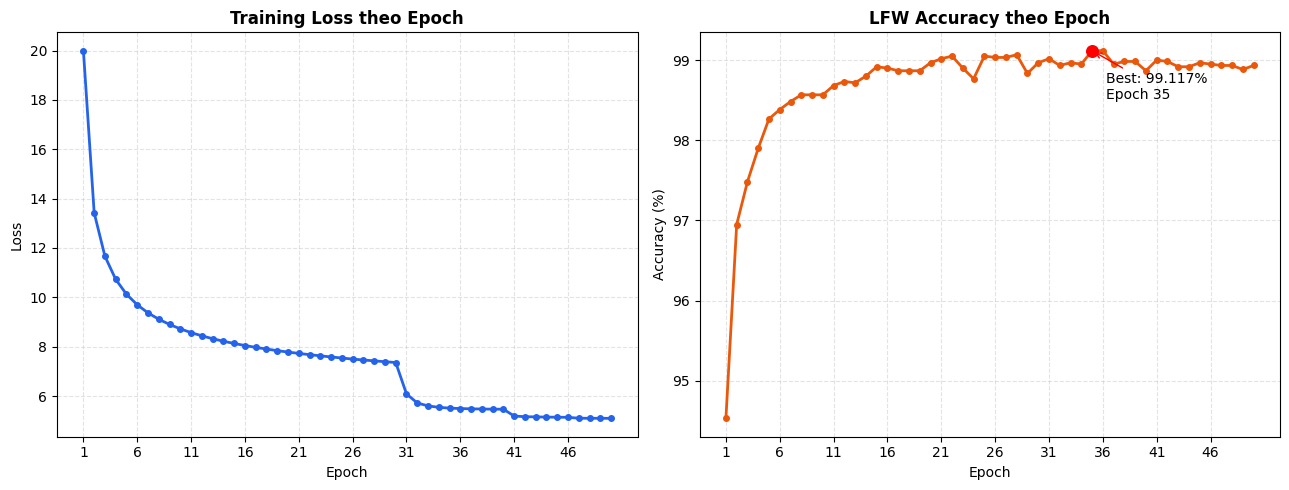

Đã lưu biểu đồ tại: /content/drive/MyDrive/arcface_casia4/logs/training_loss_lfw_accuracy.png


In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Đọc lịch sử huấn luyện
if LOG_PATH.exists():
    with open(LOG_PATH, "r", encoding="utf-8") as f:
        plot_history = json.load(f)
elif "history" in globals() and history:
    plot_history = history
else:
    raise FileNotFoundError("Không tìm thấy history.json hoặc biến history.")

# Sắp xếp và loại epoch bị ghi trùng khi resume
history_by_epoch = {
    int(item["epoch"]): item
    for item in plot_history
}
plot_history = [
    history_by_epoch[epoch]
    for epoch in sorted(history_by_epoch)
]

epochs = [item["epoch"] for item in plot_history]
train_loss = [item["tr_loss"] for item in plot_history]

lfw_rows = [
    item for item in plot_history
    if item.get("lfw_acc") is not None
]
lfw_epochs = [item["epoch"] for item in lfw_rows]
lfw_accuracy = [item["lfw_acc"] for item in lfw_rows]

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Training Loss
axes[0].plot(
    epochs,
    train_loss,
    color="#2563EB",
    linewidth=2,
    marker="o",
    markersize=4
)
axes[0].set_title("Training Loss theo Epoch", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(epochs[::max(1, len(epochs) // 10)])
axes[0].grid(True, linestyle="--", alpha=0.35)

# LFW Accuracy
axes[1].plot(
    lfw_epochs,
    lfw_accuracy,
    color="#EA580C",
    linewidth=2,
    marker="o",
    markersize=4
)
axes[1].set_title("LFW Accuracy theo Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_xticks(lfw_epochs[::max(1, len(lfw_epochs) // 10)])
axes[1].grid(True, linestyle="--", alpha=0.35)

# Đánh dấu kết quả LFW tốt nhất
if lfw_accuracy:
    best_index = int(np.argmax(lfw_accuracy))
    best_epoch = lfw_epochs[best_index]
    best_accuracy = lfw_accuracy[best_index]

    axes[1].scatter(
        best_epoch,
        best_accuracy,
        color="red",
        s=70,
        zorder=5
    )
    axes[1].annotate(
        f"Best: {best_accuracy:.3f}%\nEpoch {best_epoch}",
        xy=(best_epoch, best_accuracy),
        xytext=(10, -35),
        textcoords="offset points",
        arrowprops={"arrowstyle": "->", "color": "red"}
    )

plt.tight_layout()

# Lưu ảnh chất lượng cao để chèn vào báo cáo
output_path = LOG_DIR / "training_loss_lfw_accuracy.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Đã lưu biểu đồ tại: {output_path}")

## Inference & Verification

In [17]:
@torch.no_grad()
def get_embedding(model, img_input, device, use_flip=True):
    """
    Trích xuất embedding theo repo gốc.
    use_flip=True: concat(orig, flip) → 256-dim (khớp với LFW eval)
    use_flip=False: chỉ orig → 128-dim (nhanh hơn cho realtime)

    img_input: path str/Path | PIL.Image | Tensor(1,3,112,96)
    """
    if isinstance(img_input, (str, Path)):
        img_input = Image.open(img_input).convert('RGB')
    model.eval()

    if isinstance(img_input, Image.Image):
        t_orig = T_eval(img_input).unsqueeze(0).to(device)
        e_orig = model(t_orig).float()  # (1, 128)
        if use_flip:
            t_flip = T_eval(img_input.transpose(Image.FLIP_LEFT_RIGHT)).unsqueeze(0).to(device)
            e_flip = model(t_flip).float()
            emb = torch.cat([e_orig, e_flip], dim=1)  # (1, 256)
        else:
            emb = e_orig
    else:
        emb = model(img_input.to(device)).float()

    # L2 normalize
    return F.normalize(emb, dim=1).cpu()


def is_same_person(emb1, emb2, threshold=0.30):
    """
    Cosine similarity → verify.
    threshold nên lấy từ lfw_thresh trả về bởi evaluate_lfw().
    """
    sim = (emb1 * emb2).sum().item()
    return sim >= threshold, sim


# ─── Load best model ──────────────────────────────────────────────────────
ckpt = torch.load(str(BEST_PATH), map_location=device, weights_only=False)
net.load_state_dict(ckpt['net_state_dict'])
net.eval()
print(f'Best model loaded — LFW acc = {ckpt.get("best_lfw_acc", 0.0)*100:.3f}%')
print(f'Embedding dim: {EMBEDDING_SIZE} (single) / {EMBEDDING_SIZE*2} (flip-concat)')

# Ví dụ:
# emb_a = get_embedding(net, 'face_a.jpg', device, use_flip=True)  # (1, 256)
# emb_b = get_embedding(net, 'face_b.jpg', device, use_flip=True)  # (1, 256)
# same, score = is_same_person(emb_a, emb_b, threshold=0.30)
# print(f'Score={score:.4f} → {"SAME" if same else "DIFFERENT"}')

Best model loaded — LFW acc = 99.117%
Embedding dim: 128 (single) / 256 (flip-concat)
